In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.getcwd()
os.listdir()


['.config', 'drive', 'sample_data']

In [3]:

os.chdir(r'drive/MyDrive/Colab Notebooks/Give Me Some Credit')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import optuna


In [5]:
df = pd.read_csv('cs-training.csv')

In [6]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [8]:
df.duplicated().sum()

np.int64(0)

TypeError: 'Figure' object is not subscriptable

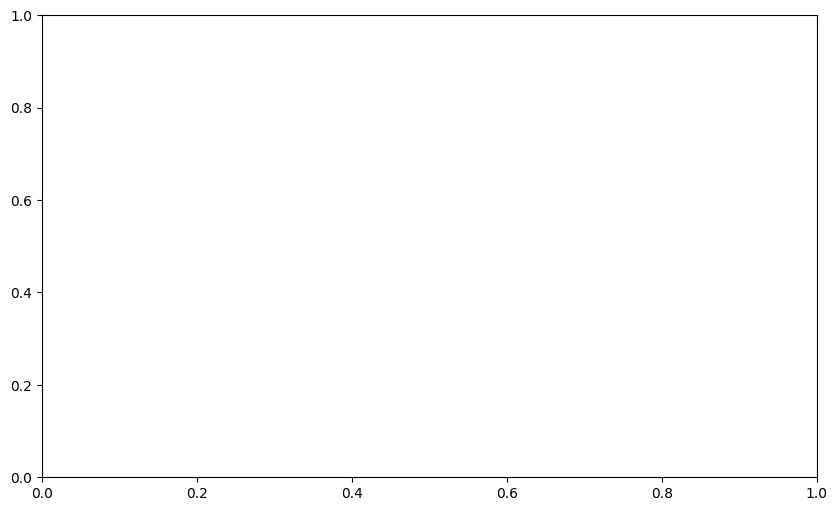

In [11]:
ax ,fig = plt.subplots(figsize=(10, 6))
ax[0,0].set_title('Count of Serious Delinquency')
ax[0,0].sns.countplot(x='SeriousDlqin2yrs', data=df, ax=ax[0,0])
ax[0,1].set_title('Age Distribution by Serious Delinquency')
ax[0,1].sns.barplot(x='SeriousDlqin2yrs', y='age', data=df, ax=ax[0,1])
ax[1,0].set_title('Monthly Income Distribution by Serious Delinquency')
ax[1,0].sns.barplot(x='SeriousDlqin2yrs', y='MonthlyIncome', data=df, ax=ax[1,0])
ax[1,1].set_title('Debt Ratio Distribution by Serious Delinquency')
ax[1,1].sns.barplot(x='SeriousDlqin2yrs', y='DebtRatio', data=df, ax=ax[1,1])
ax[2,0].sns.barplot(x='SeriousDlqin2yrs', y='NumberRealEstateLoansOrLines', data=df, ax=ax[2,0])
ax[2,1].sns.barplot(x='SeriousDlqin2yrs', y='NumberOfOpenCreditLinesAndLoans', data=df, ax=ax[2,1])
ax[3,0].sns.barplot(x='SeriousDlqin2yrs', y='NumberOfDependents', data=df, ax=ax[3,0])

<Axes: xlabel='SeriousDlqin2yrs', ylabel='count'>

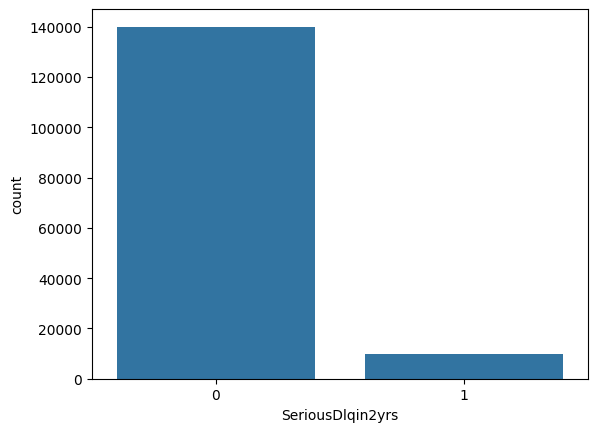

In [9]:
sns.countplot(x='SeriousDlqin2yrs', data=df)

KeyboardInterrupt: 

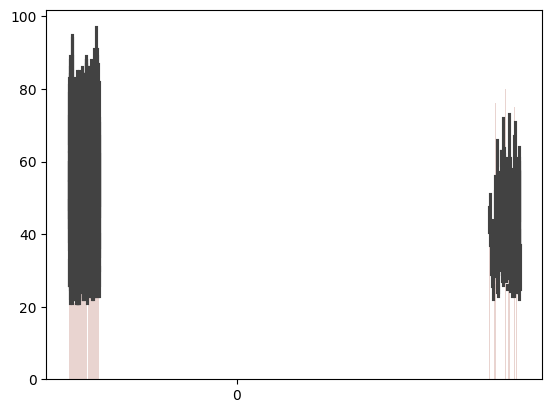

In [10]:
sns.barplot(x='SeriousDlqin2yrs', y='age', data=df)




<Axes: xlabel='SeriousDlqin2yrs', ylabel='MonthlyIncome'>

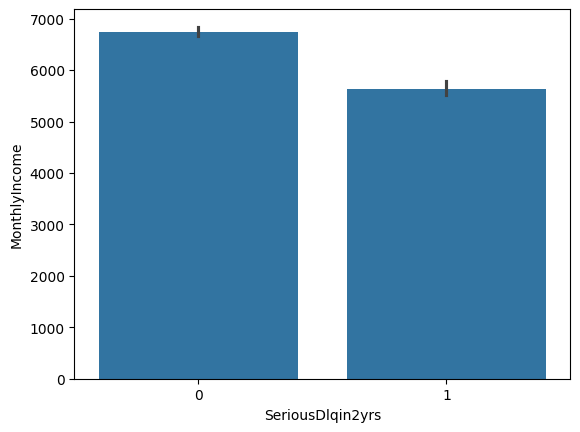

In [47]:
sns.barplot(x='SeriousDlqin2yrs', y='MonthlyIncome', data=df)

<Axes: xlabel='SeriousDlqin2yrs', ylabel='DebtRatio'>

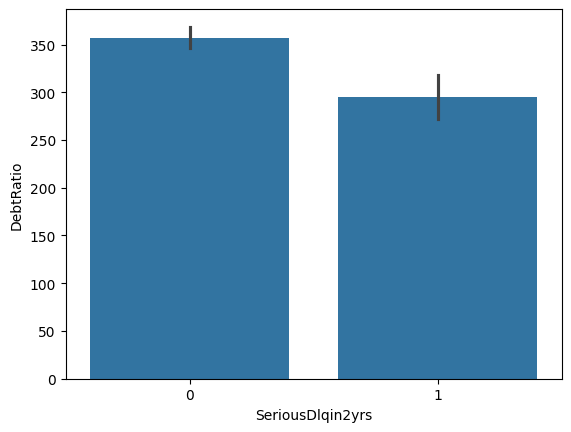

In [48]:
sns.barplot(x='SeriousDlqin2yrs', y='DebtRatio', data=df)

<Axes: xlabel='SeriousDlqin2yrs', ylabel='NumberRealEstateLoansOrLines'>

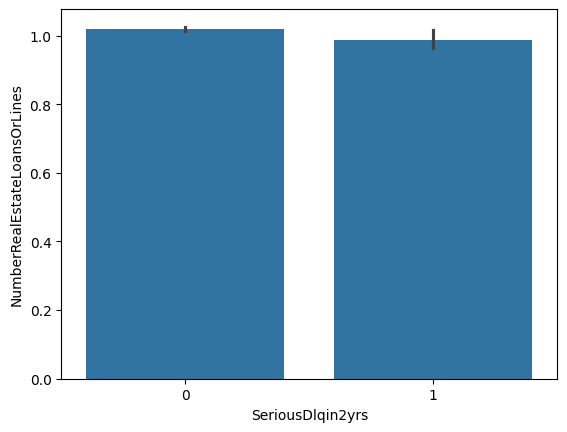

In [49]:

sns.barplot(x='SeriousDlqin2yrs', y='NumberRealEstateLoansOrLines', data=df)

<Axes: xlabel='SeriousDlqin2yrs', ylabel='NumberOfOpenCreditLinesAndLoans'>

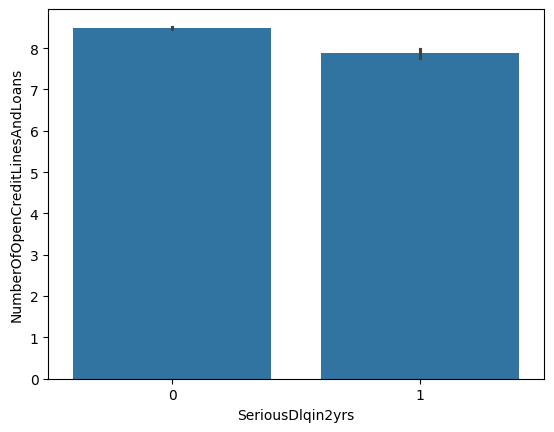

In [50]:

sns.barplot(x='SeriousDlqin2yrs', y='NumberOfOpenCreditLinesAndLoans', data=df)

In [17]:
# sns.pairplot(df, hue='SeriousDlqin2yrs')

In [18]:
df.corr()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
Unnamed: 0,1.000000,0.002801,0.002372,0.004403,-0.000571,-0.002906,0.002632,0.004586,-0.001104,-0.000666,-0.000777,-0.000055
SeriousDlqin2yrs,0.002801,1.000000,-0.001802,-0.115386,0.125587,-0.007602,-0.019746,-0.029669,0.117175,-0.007038,0.102261,0.046048
RevolvingUtilizationOfUnsecuredLines,0.002372,-0.001802,1.000000,-0.005898,-0.001314,0.003961,0.007124,-0.011281,-0.001061,0.006235,-0.001048,0.001557
age,0.004403,-0.115386,-0.005898,1.000000,-0.062995,0.024188,0.037717,0.147705,-0.061005,0.033150,-0.057159,-0.213303
NumberOfTime30-59DaysPastDueNotWorse,-0.000571,0.125587,-0.001314,-0.062995,1.000000,-0.006542,-0.010217,-0.055312,0.983603,-0.030565,0.987005,-0.002680
DebtRatio,-0.002906,-0.007602,0.003961,0.024188,-0.006542,1.000000,-0.028712,0.049565,-0.008320,0.120046,-0.007533,-0.040673
MonthlyIncome,0.002632,-0.019746,0.007124,0.037717,-0.010217,-0.028712,1.000000,0.091455,-0.012743,0.124959,-0.011116,0.062647
NumberOfOpenCreditLinesAndLoans,0.004586,-0.029669,-0.011281,0.147705,-0.055312,0.049565,0.091455,1.000000,-0.079984,0.433959,-0.071077,0.065322
NumberOfTimes90DaysLate,-0.001104,0.117175,-0.001061,-0.061005,0.983603,-0.008320,-0.012743,-0.079984,1.000000,-0.045205,0.992796,-0.010176
NumberRealEstateLoansOrLines,-0.000666,-0.007038,0.006235,0.033150,-0.030565,0.120046,0.124959,0.433959,-0.045205,1.000000,-0.039722,0.124684


<Axes: >

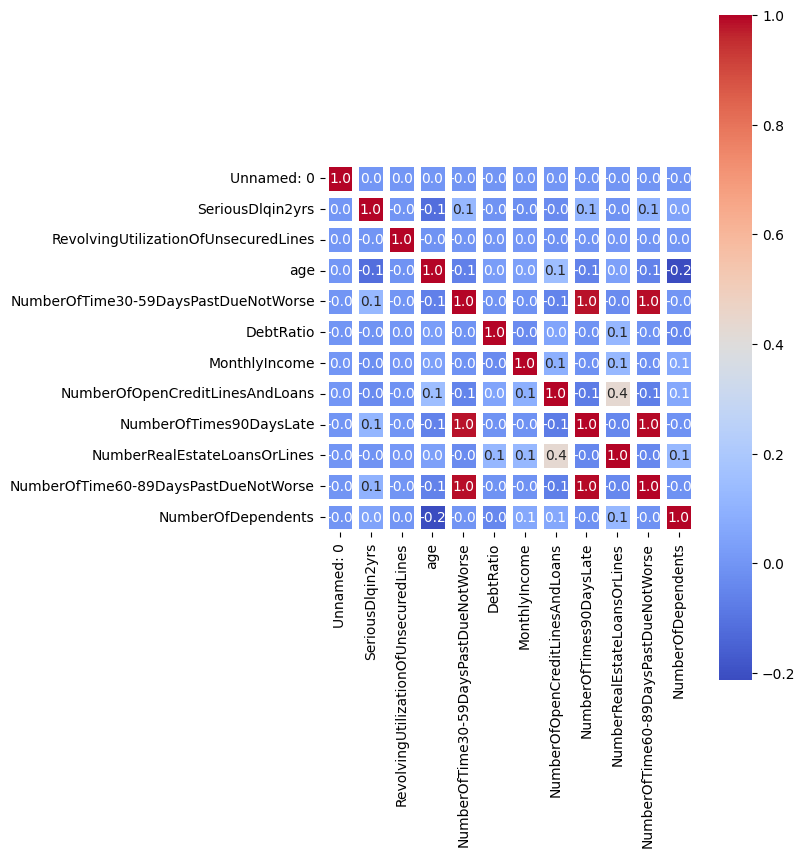

In [19]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=5, linecolor='white', fmt='.01f', cbar_kws={'shrink': 1.8}, square=True)

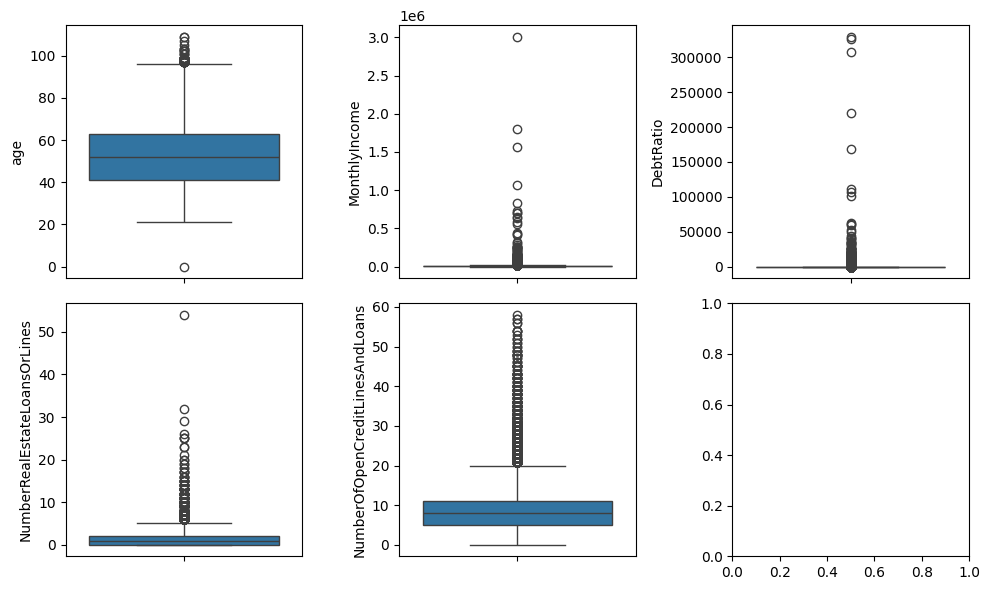

In [21]:
fig, ax = plt.subplots(2, 3, figsize=(10, 6))
ax[0,0] = sns.boxplot(y='age', data=df, ax=ax[0,0])
ax[0,1] = sns.boxplot(y='MonthlyIncome', data=df, ax=ax[0,1])
ax[0,2] = sns.boxplot(y='DebtRatio', data=df, ax=ax[0,2])
ax[1,0] = sns.boxplot(y='NumberRealEstateLoansOrLines', data=df, ax=ax[1,0])
ax[1,1] = sns.boxplot(y='NumberOfOpenCreditLinesAndLoans', data=df, ax=ax[1,1])
plt.tight_layout()
plt.show()

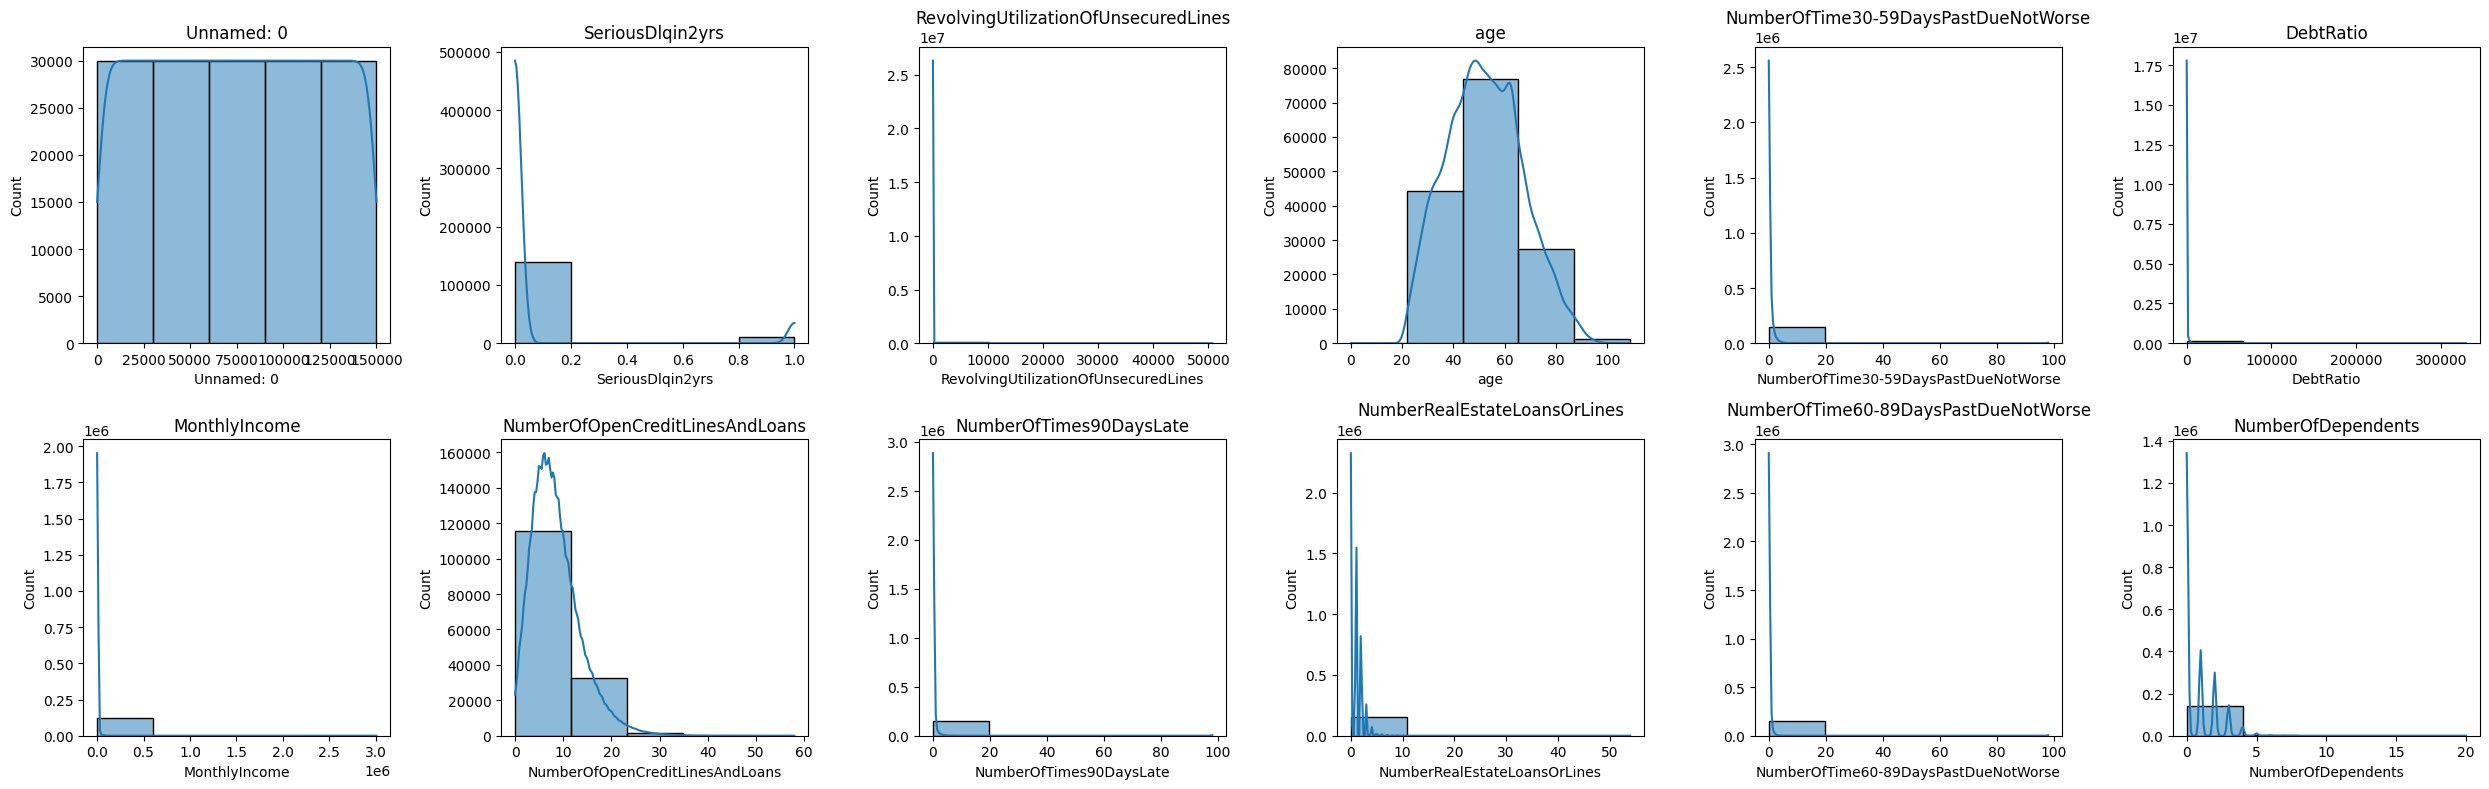

In [ ]:
features = ['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents']

fig, ax = plt.subplots(2, 6, figsize=(25, 8))
ax = ax.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], bins=5, kde=True, ax=ax[i])
    ax[i].set_title(col)
    ax[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [ ]:
df.skew()

,0
Unnamed: 0,0.000000
SeriousDlqin2yrs,3.468857
RevolvingUtilizationOfUnsecuredLines,97.631574
age,0.188995
NumberOfTime30-59DaysPastDueNotWorse,22.597108
DebtRatio,95.157793
MonthlyIncome,114.040318
NumberOfOpenCreditLinesAndLoans,1.215314
NumberOfTimes90DaysLate,23.087345
NumberRealEstateLoansOrLines,3.482484


In [ ]:
df['RevolvingUtilizationOfUnsecuredLines'].describe()

,RevolvingUtilizationOfUnsecuredLines
count,150000.000000
mean,6.048438
std,249.755371
min,0.000000
25%,0.029867
50%,0.154181
75%,0.559046
max,50708.000000


In [22]:
X = df.drop(['SeriousDlqin2yrs', 'Unnamed: 0'], axis=1)
y = df['SeriousDlqin2yrs']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X_train.isnull().sum()

,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,23689
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0
NumberOfDependents,3127


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Columns
num_cols = [
    'age', 'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio',
    'MonthlyIncome', 'NumberOfTimes90DaysLate',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

log_col = ['NumberOfOpenCreditLinesAndLoans']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   
    ('pt', PowerTransformer()),
    ('scaler', StandardScaler())
])
Transformer = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('log', FunctionTransformer(func=np.log1p), log_col)
], remainder='passthrough')

final_pipeline = Pipeline([
    ('preprocessing', Transformer)
])

final_pipeline.fit(X_train)

X_train_transformed = final_pipeline.transform(X_train)
X_test_transformed  = final_pipeline.transform(X_test)

In [26]:
lg_clf = LogisticRegression()
lg_clf_score = cross_val_score(lg_clf, X_train_transformed, y_train, cv=5, scoring='roc_auc').mean()

In [27]:
xgb_clf = xgb.XGBClassifier()
xgb_clf_score = cross_val_score(xgb_clf, X_train_transformed, y_train, cv=5, scoring='roc_auc').mean()

In [29]:
rfc_clf =  BalancedRandomForestClassifier(random_state=42, n_estimators=50)
rfc_clf_score = cross_val_score(rfc_clf, X_train_transformed, y_train, cv=3, scoring='roc_auc').mean()

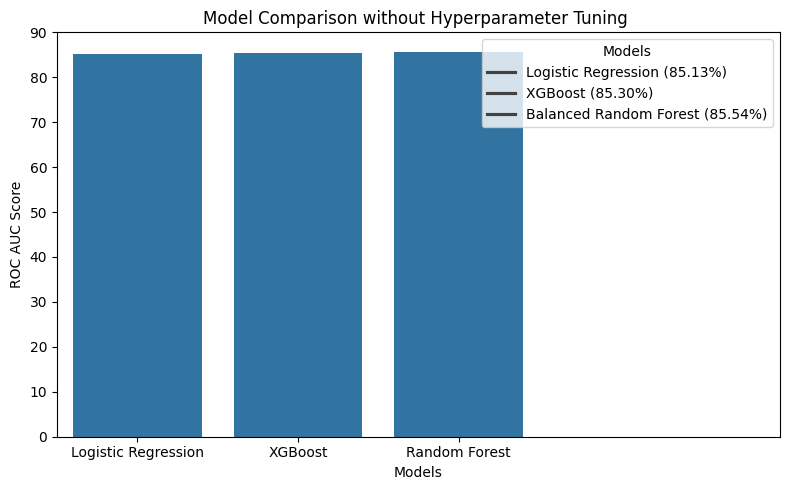

In [30]:
sns.barplot(x=['Logistic Regression', 'XGBoost', 'Random Forest'], y=[lg_clf_score*100, xgb_clf_score*100, rfc_clf_score*100], figure=plt.figure(figsize=(8, 5)))
plt.xlabel('Models')
plt.ylabel('ROC AUC Score')
plt.ylim(0,90) 
plt.xlim(-0.5,4) 
plt.title('Model Comparison without Hyperparameter Tuning ')
plt.legend(title='Models', labels=[f'Logistic Regression ({lg_clf_score*100:.2f}%)', f'XGBoost ({xgb_clf_score*100:.2f}%)', f'Balanced Random Forest ({rfc_clf_score*100:.2f}%)'], loc='upper right')
plt.tight_layout()
plt.show()


In [31]:
def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['xgb', 'BalancedRandomForestClassifier', 'LogisticRegression'])

    if classifier_name == 'xgb':
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 20)

        model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth
        )

    elif classifier_name == 'BalancedRandomForestClassifier':
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
        max_features= trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])
        replacement = trial.suggest_categorical('replacement', [True, False])

        model = BalancedRandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            criterion = criterion,
            max_features= max_features,
            bootstrap=bootstrap,
            replacement = replacement
        )
    elif classifier_name == 'LogisticRegression':
        C = trial.suggest_float('C', 0.01, 100, log=True)
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
        solver = trial.suggest_categorical('solver', ['liblinear', 'saga'])
        max_iter= trial.suggest_int('max_iter', 100, 500)

        model = LogisticRegression(C=C, penalty=penalty, solver=solver, random_state=42, max_iter= max_iter)


    score = cross_val_score(model, X_train_transformed, y_train, cv=3, scoring='roc_auc').mean()
    return score

In [ ]:
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=100)

[I 2026-04-15 19:18:22,632] A new study created in memory with name: no-name-84c12264-e151-417d-be6c-0c1c7b26c47b
[I 2026-04-15 19:18:33,882] Trial 0 finished with value: 0.8632816729919822 and parameters: {'classifier': 'BalancedRandomForestClassifier', 'n_estimators': 132, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 7, 'criterion': 'gini', 'max_features': 'log2', 'bootstrap': False, 'replacement': True}. Best is trial 0 with value: 0.8632816729919822.
[I 2026-04-15 19:18:34,208] Trial 1 finished with value: 0.8512640534428547 and parameters: {'classifier': 'LogisticRegression', 'C': 0.2989077587002307, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 345}. Best is trial 0 with value: 0.8632816729919822.
[I 2026-04-15 19:18:38,008] Trial 2 finished with value: 0.8146198766023773 and parameters: {'classifier': 'xgb', 'n_estimators': 200, 'learning_rate': 0.26244451700383037, 'max_depth': 18}. Best is trial 0 with value: 0.8632816729919822.
[I 2026-04-15 19:18:38,982

In [32]:
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

NameError: name 'study' is not defined

In [ ]:
std =study.trials_dataframe()

In [ ]:
std[std['params_classifier'] == 'xgb'].sort_values(by='value', ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_C,params_bootstrap,params_classifier,params_criterion,params_learning_rate,params_max_depth,params_max_features,params_max_iter,params_min_samples_leaf,params_min_samples_split,params_n_estimators,params_penalty,params_replacement,params_solver,state
3,3,0.862660,2026-04-15 19:18:38.009408,2026-04-15 19:18:38.981990,0 days 00:00:00.972582,NaN,NaN,xgb,NaN,0.020717,6.0,NaN,NaN,NaN,NaN,136.0,NaN,NaN,NaN,COMPLETE
96,96,0.859583,2026-04-15 19:42:46.217017,2026-04-15 19:42:49.451551,0 days 00:00:03.234534,NaN,NaN,xgb,NaN,0.010639,9.0,NaN,NaN,NaN,NaN,276.0,NaN,NaN,NaN,COMPLETE
16,16,0.850101,2026-04-15 19:20:08.290351,2026-04-15 19:20:12.472297,0 days 00:00:04.181946,NaN,NaN,xgb,NaN,0.010894,13.0,NaN,NaN,NaN,NaN,173.0,NaN,NaN,NaN,COMPLETE
27,27,0.845118,2026-04-15 19:22:33.848747,2026-04-15 19:22:37.202442,0 days 00:00:03.353695,NaN,NaN,xgb,NaN,0.052075,12.0,NaN,NaN,NaN,NaN,247.0,NaN,NaN,NaN,COMPLETE
19,19,0.844227,2026-04-15 19:20:37.138400,2026-04-15 19:20:38.417977,0 days 00:00:01.279577,NaN,NaN,xgb,NaN,0.127946,12.0,NaN,NaN,NaN,NaN,81.0,NaN,NaN,NaN,COMPLETE
59,59,0.844099,2026-04-15 19:32:41.872114,2026-04-15 19:32:47.819413,0 days 00:00:05.947299,NaN,NaN,xgb,NaN,0.025711,15.0,NaN,NaN,NaN,NaN,238.0,NaN,NaN,NaN,COMPLETE
35,35,0.841951,2026-04-15 19:25:14.962240,2026-04-15 19:25:19.178899,0 days 00:00:04.216659,NaN,NaN,xgb,NaN,0.048103,13.0,NaN,NaN,NaN,NaN,268.0,NaN,NaN,NaN,COMPLETE
48,48,0.831905,2026-04-15 19:28:55.440719,2026-04-15 19:28:58.113652,0 days 00:00:02.672933,NaN,NaN,xgb,NaN,0.144523,10.0,NaN,NaN,NaN,NaN,283.0,NaN,NaN,NaN,COMPLETE
2,2,0.814620,2026-04-15 19:18:34.209011,2026-04-15 19:18:38.008641,0 days 00:00:03.799630,NaN,NaN,xgb,NaN,0.262445,18.0,NaN,NaN,NaN,NaN,200.0,NaN,NaN,NaN,COMPLETE
77,77,0.810390,2026-04-15 19:37:41.417243,2026-04-15 19:37:44.641865,0 days 00:00:03.224622,NaN,NaN,xgb,NaN,0.297085,12.0,NaN,NaN,NaN,NaN,276.0,NaN,NaN,NaN,COMPLETE


In [ ]:
best_lr  = std[std['params_classifier'] == 'LogisticRegression'].sort_values(by='value', ascending=False).head(1)
best_xgb = std[std['params_classifier'] == 'xgb'].sort_values(by='value', ascending=False).head(1)
best_rf  = std[std['params_classifier'] == 'BalancedRandomForestClassifier'].sort_values(by='value', ascending=False).head(1)

In [ ]:
best_rf

,number,value,datetime_start,datetime_complete,duration,params_C,params_bootstrap,params_classifier,params_criterion,params_learning_rate,params_max_depth,params_max_features,params_max_iter,params_min_samples_leaf,params_min_samples_split,params_n_estimators,params_penalty,params_replacement,params_solver,state
54,54,0.864577,2026-04-15 19:31:19.477711,2026-04-15 19:31:38.244797,0 days 00:00:18.767086,NaN,True,BalancedRandomForestClassifier,entropy,NaN,11.0,log2,NaN,5.0,7.0,263.0,NaN,False,NaN,COMPLETE


In [42]:
from sklearn.metrics import accuracy_score


lg_clf2 = LogisticRegression(C=0.011118 , penalty='l2', solver='saga')
lg_clf_score2v = cross_val_score(lg_clf2, X_train_transformed, y_train, cv=5, scoring='roc_auc').mean()
lg_clf2.fit(X_train_transformed, y_train)
pred = lg_clf2.predict_proba(X_test_transformed)[:, 1]
sr_lg = roc_auc_score(y_test, pred)

In [43]:
xgb_clf2 = xgb.XGBClassifier(learning_rate=0.104253, max_depth=8, n_estimators=184)
xgb_clf_score2v = cross_val_score(xgb_clf2, X_train_transformed, y_train, cv=5, scoring='roc_auc').mean()
xgb_clf2.fit(X_train_transformed, y_train)
pred = xgb_clf2.predict_proba(X_test_transformed)[:, 1]
sr_xgb = roc_auc_score(y_test, pred)

In [44]:
rfc_clf2 =  BalancedRandomForestClassifier(random_state=42,max_depth=12, min_samples_leaf=10, min_samples_split=8, n_estimators=100)
rfc_clf_score2v = cross_val_score(rfc_clf2, X_train_transformed, y_train, cv=3, scoring='roc_auc').mean()
rfc_clf2.fit(X_train_transformed, y_train)
pred = rfc_clf2.predict_proba(X_test_transformed)[:, 1]

sr_rfc = roc_auc_score(y_test, pred)

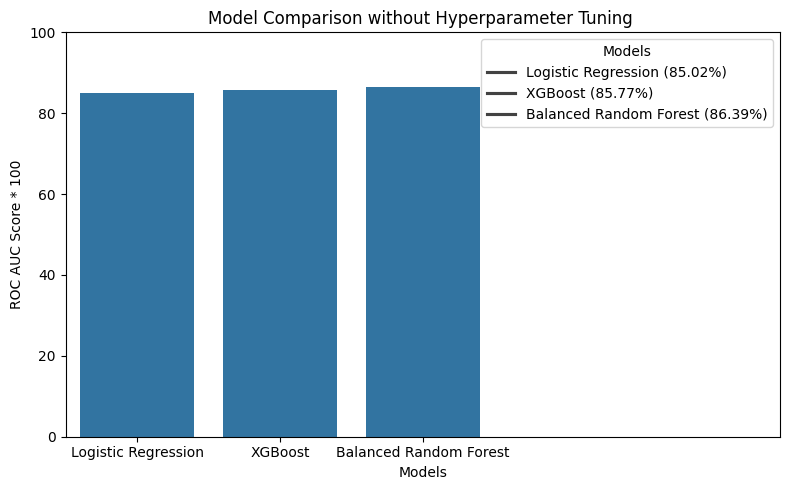

In [45]:
sns.barplot(x=['Logistic Regression', 'XGBoost', 'Balanced Random Forest'], y=[sr_lg*100, sr_xgb*100, sr_rfc*100], figure=plt.figure(figsize=(8, 5)))
plt.xlabel('Models')
plt.ylabel('ROC AUC Score * 100')
plt.ylim(0,100) 
plt.xlim(-0.5,4.5) 
plt.title('Model Comparison without Hyperparameter Tuning ')
plt.legend(title='Models', labels=[f'Logistic Regression ({sr_lg*100:.2f}%)', f'XGBoost ({sr_xgb*100:.2f}%)', f'Balanced Random Forest ({sr_rfc*100:.2f}%)'], loc='upper right')
plt.tight_layout()
plt.show()
